# NBA Draft Success Model

**Target:** Career Points Per Game (PPG)  
**Features:** Draft position, combine measurements, position, international flag  
**Approach:** 10% stratified random holdout per draft class (2000–2020)

> Players drafted after 2020 are excluded — careers still too early to evaluate.  
> Players who never appeared in play-by-play are included with PPG = 0 (busts).

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

FEATURES_PATH     = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\features.csv"
CAREER_STATS_PATH = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\player_career_stats.csv"

features = pd.read_csv(FEATURES_PATH)
career   = pd.read_csv(CAREER_STATS_PATH)
print(f"Features: {features.shape}")
print(f"Career stats: {career.shape}")

Features: (1425, 19)
Career stats: (1198, 10)


## Step 1 — Build Target from Career Stats

Recompute win-share proxy directly here so this notebook is self-contained.

In [42]:
import sqlite3

DB_PATH = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\nba.sqlite"
conn = sqlite3.connect(DB_PATH)

conn.execute("DROP TABLE IF EXISTS temp_valid_players")
conn.execute("""
    CREATE TEMPORARY TABLE temp_valid_players AS
    SELECT DISTINCT person_id AS player_id FROM draft_history WHERE season >= 2000
""")
conn.commit()

three_pm = pd.read_sql_query("""
    SELECT p.player1_id AS player_id, COUNT(*) AS three_pm
    FROM play_by_play p
    JOIN temp_valid_players v ON p.player1_id = v.player_id
    WHERE p.eventmsgtype = 1
      AND (p.homedescription LIKE '%3PT%' OR p.visitordescription LIKE '%3PT%')
    GROUP BY p.player1_id
""", conn)

ftm = pd.read_sql_query("""
    SELECT p.player1_id AS player_id, COUNT(*) AS ftm
    FROM play_by_play p
    JOIN temp_valid_players v ON p.player1_id = v.player_id
    WHERE p.eventmsgtype = 3
      AND p.player1_id IS NOT NULL AND p.player1_id != 0
      AND (
          (p.homedescription IS NOT NULL AND p.homedescription NOT LIKE '%MISS%')
          OR (p.visitordescription IS NOT NULL AND p.visitordescription NOT LIKE '%MISS%')
      )
    GROUP BY p.player1_id
""", conn)

three_pm['player_id'] = three_pm['player_id'].astype('int64')
ftm['player_id']      = ftm['player_id'].astype('int64')

target = career.merge(three_pm, on='player_id', how='left')
target = target.merge(ftm,      on='player_id', how='left')
target[['three_pm', 'ftm']] = target[['three_pm', 'ftm']].fillna(0).astype(int)

target['two_pm']    = target['fgm'] - target['three_pm']
target['total_pts'] = 2 * target['two_pm'] + 3 * target['three_pm'] + target['ftm']
target['target_ppg'] = (target['total_pts'] / target['games_played']).round(2)

print(f"Target built for {len(target)} players")
target[['player_name', 'games_played', 'total_pts', 'target_ppg']].head()

Target built for 1198 players


,player_name,games_played,total_pts,target_ppg
0,Andrew Bogut,693,6317,9.12
1,Marvin Williams,974,9862,10.13
2,Chris Paul,1207,21782,18.05
3,Raymond Felton,857,9226,10.77
4,Martell Webster,480,3973,8.28


## Step 2 — Join Features + Target, Apply Filters

In [43]:
# Left join from features so drafted players who never played get PPG = 0
df = features.merge(
    target[['player_id', 'player_name', 'games_played', 'target_ppg']],
    on='player_id', how='left'
)

# Players with no play-by-play record are busts — PPG = 0, games = 0
df['target_ppg']   = df['target_ppg'].fillna(0)
df['games_played'] = df['games_played'].fillna(0)

# Only exclude draft years too recent to evaluate
df = df[df['draft_year'] <= 2020]

print(f"Modeling dataset: {len(df)} players")
print(f"Draft years: {df['draft_year'].min()} – {df['draft_year'].max()}")
print(f"Players with PPG = 0 (never played): {(df['target_ppg'] == 0).sum()}")
df.head()

Modeling dataset: 1249 players
Draft years: 2000 – 2020
Players with PPG = 0 (never played): 158


,player_id,draft_year,round_number,overall_pick,from_college,height_wo_shoes,weight,wingspan,standing_reach,standing_vertical_leap,...,three_quarter_sprint,is_international,has_combine,pos_C,pos_F,pos_G,pos_Unknown,player_name,games_played,target_ppg
0,2030,2000,1,1,1,77.75,213.0,82.75,103.75,30.0,...,3.26,NaN,0,False,False,False,False,Kenyon Martin,747.0,12.30
1,2031,2000,1,2,1,77.75,213.0,82.75,103.75,30.0,...,3.26,0.0,0,False,True,False,False,Stromile Swift,492.0,8.42
2,2032,2000,1,3,0,77.75,213.0,82.75,103.75,30.0,...,3.26,NaN,0,False,False,False,False,Darius Miles,399.0,10.11
3,2033,2000,1,4,1,77.75,213.0,82.75,103.75,30.0,...,3.26,0.0,0,False,False,False,True,Marcus Fizer,252.0,9.25
4,2034,2000,1,5,1,77.75,213.0,82.75,103.75,30.0,...,3.26,0.0,0,False,False,True,False,Mike Miller,947.0,10.37


## Step 3 — Stratified 10% Holdout per Draft Class

Hold out 10% of players randomly from each draft year so the test set represents all eras equally.

In [44]:
FEATURE_COLS = [
    'from_college', 'is_international', 'has_combine',
    'height_wo_shoes', 'wingspan',
    'standing_vertical_leap', 'max_vertical_leap',
    'lane_agility_time'
] + [c for c in df.columns if c.startswith('pos_')]

# 10% random holdout from each draft class
np.random.seed(42)
test_idx  = []
train_idx = []

for year, group in df.groupby('draft_year'):
    n_test = max(1, round(len(group) * 0.10))
    sampled = group.sample(n=n_test, random_state=42).index
    test_idx.extend(sampled)
    train_idx.extend(group.index.difference(sampled))

train = df.loc[train_idx]
test  = df.loc[test_idx]

X_train = train[FEATURE_COLS]
y_train = train['target_ppg']
X_test  = test[FEATURE_COLS]
y_test  = test['target_ppg']

print(f"Train: {len(train)} players")
print(f"Test:  {len(test)} players")
print(f"\nTest players per draft year:")
print(test.groupby('draft_year').size())

Train: 1123 players
Test:  126 players

Test players per draft year:
draft_year
2000    6
2001    6
2002    6
2003    6
2004    6
2005    6
2006    6
2007    6
2008    6
2009    6
2010    6
2011    6
2012    6
2013    6
2014    6
2015    6
2016    6
2017    6
2018    6
2019    6
2020    6
dtype: int64


## Step 4 — Baseline: Predict by Draft Pick Alone

In [45]:
# Baseline: predict global median PPG for every player
global_median  = y_train.median()
baseline_preds = pd.Series(global_median, index=y_test.index)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2   = r2_score(y_test, baseline_preds)
baseline_rho  = spearmanr(y_test, baseline_preds).correlation

print(f"Baseline (global median: {global_median:.1f} PPG)")
print(f"  RMSE:          {baseline_rmse:.2f}")
print(f"  R²:            {baseline_r2:.3f}")
print(f"  Spearman rho:  {baseline_rho:.3f}")

Baseline (global median: 5.5 PPG)
  RMSE:          6.80
  R²:            -0.145
  Spearman rho:  nan


c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


## Step 5 — Random Forest Model

In [46]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Check which columns still have NaNs
nan_cols = X_train.columns[X_train.isna().any()].tolist()
if nan_cols:
    print(f"NaN columns: {nan_cols}")
else:
    print("No NaNs in X_train")

# HistGradientBoosting handles NaNs natively — no imputation needed
hgb = HistGradientBoostingRegressor(max_iter=300, max_depth=6, random_state=42)
hgb.fit(X_train, y_train)
rf_preds = hgb.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)
rf_rho  = spearmanr(y_test, rf_preds).correlation

print(f"\nHistGradientBoosting")
print(f"  RMSE:          {rf_rmse:.2f}")
print(f"  R²:            {rf_r2:.3f}")
print(f"  Spearman rho:  {rf_rho:.3f}")
print(f"\nImprovement over baseline:")
print(f"  RMSE delta:    {baseline_rmse - rf_rmse:.2f}")
print(f"  Rho delta:     {rf_rho - baseline_rho:.3f}")

NaN columns: ['is_international']

HistGradientBoosting
  RMSE:          6.58
  R²:            -0.071
  Spearman rho:  0.157

Improvement over baseline:
  RMSE delta:    0.22
  Rho delta:     nan


## Step 6 — Feature Importance

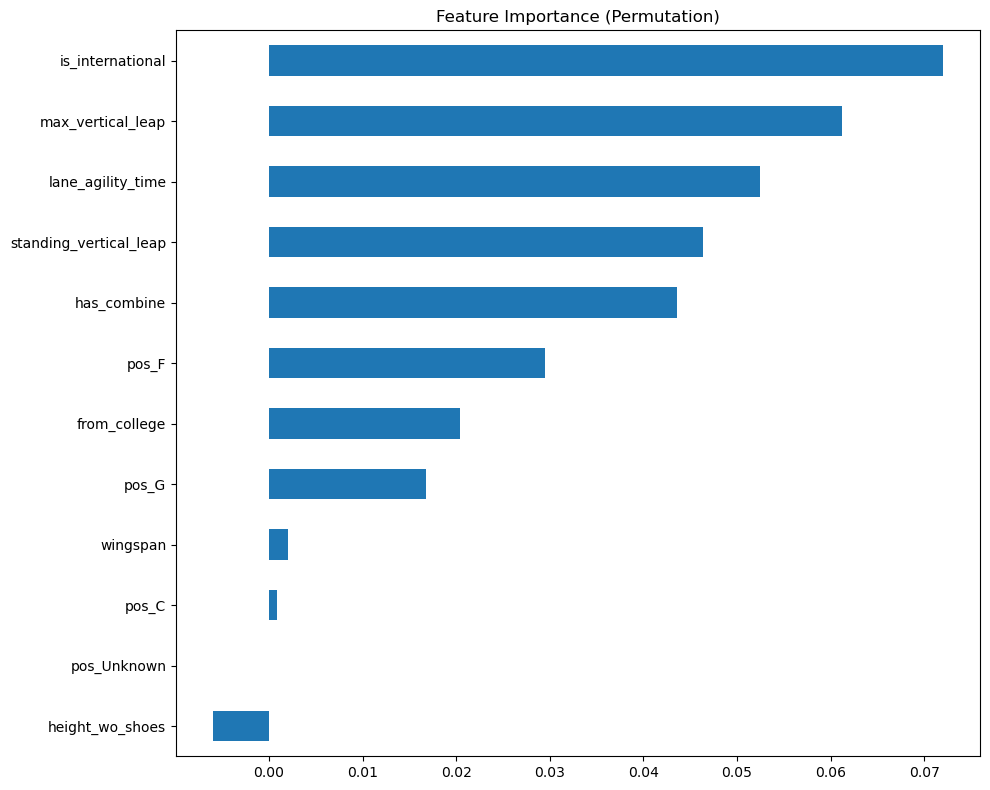

In [47]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)
importance = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(10, 8), title='Feature Importance (Permutation)')
plt.tight_layout()
plt.show()

## Step 7 — Inspect Predictions vs Actuals

In [48]:
results = test[['player_name', 'draft_year', 'overall_pick', 'target_ppg']].copy()
results['predicted'] = rf_preds.round(1)
results['error']     = (results['predicted'] - results['target_ppg']).round(1)

print("=== Biggest misses (underestimated) ===")
print(results.nsmallest(10, 'error')[['player_name', 'draft_year', 'overall_pick', 'target_ppg', 'predicted', 'error']].to_string(index=False))

print("\n=== Biggest misses (overestimated) ===")
print(results.nlargest(10, 'error')[['player_name', 'draft_year', 'overall_pick', 'target_ppg', 'predicted', 'error']].to_string(index=False))

=== Biggest misses (underestimated) ===
       player_name  draft_year  overall_pick  target_ppg  predicted  error
      LeBron James        2003             1       27.66        8.9  -18.8
Karl-Anthony Towns        2015             1       22.70        4.0  -18.7
   Zion Williamson        2019             1       25.29        7.1  -18.2
    Damian Lillard        2012             6       25.97        7.9  -18.1
     Anthony Davis        2012             1       25.32        8.2  -17.1
      Derrick Rose        2008             1       17.83        3.7  -14.1
          Yao Ming        2002             1       19.34        5.7  -13.6
   Anthony Edwards        2020             1       21.63        8.1  -13.5
    Andrew Wiggins        2014             1       18.79        6.9  -11.9
     Blake Griffin        2009             1       18.89        7.1  -11.8

=== Biggest misses (overestimated) ===
        player_name  draft_year  overall_pick  target_ppg  predicted  error
Nigel Williams-Goss

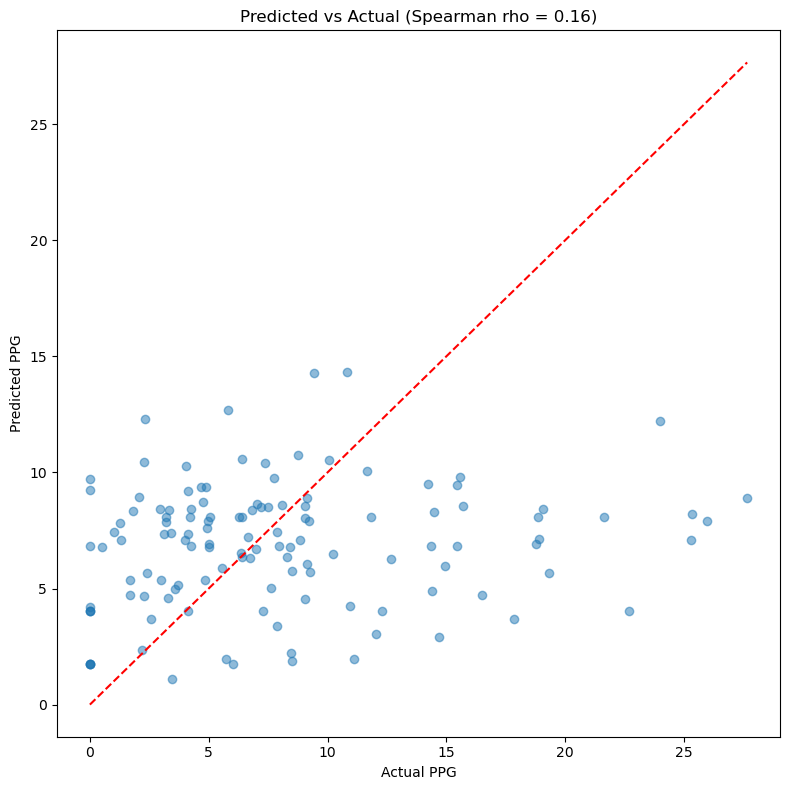

In [49]:
# Scatter: predicted vs actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual PPG')
plt.ylabel('Predicted PPG')
plt.title(f'Predicted vs Actual (Spearman rho = {rf_rho:.2f})')
plt.tight_layout()
plt.show()